# 06 — Production Monitoring: Quality, Latency & the Cost-Recall-Latency Triangle

Based on the AWS slide deck: *Build Production-Ready AI-Powered Search Applications*

## What This Notebook Covers
| Section | Topic |
|---------|-------|
| 1 | Dataset + Index (40 facts, Bedrock Titan V2, Qdrant) |
| 2 | Eval Metrics: Precision@K, Recall@K, MRR, NDCG |
| 3 | Quality benchmarks: keyword vs semantic vs hybrid |
| 4 | Latency profiling: P50 / P75 / P95 / P99 |
| 5 | Embedding latency vs search latency breakdown |
| 6 | The Cost-Latency-Recall Triangle (6 configs) |
| 7 | Decision Framework — 4-quadrant cheat-sheet |

> **Key insight from the slide deck:** *P99 tells you about the worst user experience. Click-through rate is the ultimate signal. Cost per relevant result is the best single business metric.*

## Step 1 — Install & Import

In [1]:
import subprocess, sys
pkgs = ["boto3","qdrant-client","rank_bm25","numpy","matplotlib","python-dotenv"]
subprocess.check_call([sys.executable,"-m","pip","install","--quiet"]+pkgs)
print("Packages ready.")

Packages ready.


In [2]:
from dotenv import load_dotenv
load_dotenv('../../../.env')

import os, json, time, math, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import boto3
from rank_bm25 import BM25Okapi
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    ScalarQuantization, ScalarQuantizationConfig, ScalarType,
    HnswConfigDiff, SearchParams, QuantizationSearchParams
)

plt.rcParams.update({
    "figure.facecolor":"#0f1117","axes.facecolor":"#1a1d27",
    "axes.edgecolor":"#3a3d4d","axes.labelcolor":"#e0e0e0",
    "xtick.color":"#a0a0b0","ytick.color":"#a0a0b0",
    "text.color":"#e0e0e0","grid.color":"#2a2d3d",
    "grid.linestyle":"--","grid.alpha":0.5,
    "figure.dpi":130,"font.family":"DejaVu Sans",
    "axes.titlesize":12,"axes.labelsize":10,
})
print("Imports OK")

Imports OK


## Step 2 — Configuration & Helpers

In [3]:
AWS_REGION      = os.getenv("AWS_DEFAULT_REGION","us-east-1")
EMBEDDING_MODEL = "amazon.titan-embed-text-v2:0"
EMBEDDING_DIM   = 1024
QDRANT_URL      = os.getenv("QDRANT_URL","")
QDRANT_API_KEY  = os.getenv("QDRANT_API_KEY","")

bedrock_rt = boto3.client("bedrock-runtime", region_name=AWS_REGION)

def embed(text: str) -> list:
    body = json.dumps({"inputText":text,"dimensions":EMBEDDING_DIM,"normalize":True})
    r = bedrock_rt.invoke_model(
        modelId=EMBEDDING_MODEL, body=body,
        contentType="application/json", accept="application/json"
    )
    return json.loads(r["body"].read())["embedding"]

def timed_embed(text: str):
    t0 = time.perf_counter()
    v  = embed(text)
    return v, (time.perf_counter()-t0)*1000

# Qdrant
if QDRANT_URL:
    kw = {"url":QDRANT_URL}
    if QDRANT_API_KEY: kw["api_key"] = QDRANT_API_KEY
    qc = QdrantClient(**kw)
    print(f"Qdrant Cloud: {QDRANT_URL}")
else:
    qc = QdrantClient(":memory:")
    print("Qdrant in-memory")

v_test = embed("test")
print(f"Embedding dim: {len(v_test)}, norm≈{sum(x**2 for x in v_test)**0.5:.4f}")

Qdrant in-memory


Embedding dim: 1024, norm≈1.0000


## Step 3 — Dataset: 40 Facts + Labeled Eval Queries

In [4]:
DOCS = [
    # Technology (0-9)
    {"id":0,  "text":"Python is a high-level programming language known for its simplicity and readability.","topic":"tech"},
    {"id":1,  "text":"Machine learning models learn patterns from data without being explicitly programmed.","topic":"tech"},
    {"id":2,  "text":"Neural networks are inspired by the structure of biological brains.","topic":"tech"},
    {"id":3,  "text":"Cloud computing delivers IT resources over the internet on a pay-as-you-go basis.","topic":"tech"},
    {"id":4,  "text":"Docker containers package applications with their dependencies for consistent deployment.","topic":"tech"},
    {"id":5,  "text":"Kubernetes orchestrates containerized workloads across clusters of machines.","topic":"tech"},
    {"id":6,  "text":"GraphQL is a query language for APIs that allows clients to request exactly the data they need.","topic":"tech"},
    {"id":7,  "text":"Transformers use self-attention to model relationships between all tokens in a sequence.","topic":"tech"},
    {"id":8,  "text":"Gradient descent is an optimization algorithm that minimizes a loss function iteratively.","topic":"tech"},
    {"id":9,  "text":"REST APIs use HTTP methods to expose resources through standard endpoints.","topic":"tech"},
    # Science (10-19)
    {"id":10, "text":"Photosynthesis converts sunlight, water, and carbon dioxide into glucose and oxygen.","topic":"science"},
    {"id":11, "text":"DNA is a double helix molecule that encodes genetic information in four nucleotide bases.","topic":"science"},
    {"id":12, "text":"Black holes are regions of spacetime where gravity is so strong that nothing can escape.","topic":"science"},
    {"id":13, "text":"Quantum entanglement links particles so that the state of one instantly affects the other.","topic":"science"},
    {"id":14, "text":"The periodic table organizes elements by atomic number and chemical properties.","topic":"science"},
    {"id":15, "text":"CRISPR-Cas9 is a gene editing tool that can precisely modify DNA sequences.","topic":"science"},
    {"id":16, "text":"Dark matter makes up about 27% of the universe but does not emit or reflect light.","topic":"science"},
    {"id":17, "text":"The speed of light in a vacuum is approximately 299,792 kilometres per second.","topic":"science"},
    {"id":18, "text":"Mitochondria are organelles that generate most of the cell's supply of ATP energy.","topic":"science"},
    {"id":19, "text":"Plate tectonics describes the movement of Earth's lithospheric plates over geological time.","topic":"science"},
    # History (20-29)
    {"id":20, "text":"The Roman Empire fell in 476 AD when the last emperor Romulus Augustulus was deposed.","topic":"history"},
    {"id":21, "text":"The French Revolution began in 1789 with the storming of the Bastille prison.","topic":"history"},
    {"id":22, "text":"World War I started in 1914 following the assassination of Archduke Franz Ferdinand.","topic":"history"},
    {"id":23, "text":"The Renaissance was a cultural rebirth in Europe spanning the 14th to 17th centuries.","topic":"history"},
    {"id":24, "text":"The Moon landing in 1969 was achieved by NASA's Apollo 11 mission with astronauts Armstrong and Aldrin.","topic":"history"},
    {"id":25, "text":"The Magna Carta was signed in 1215 and limited the power of the English monarchy.","topic":"history"},
    {"id":26, "text":"The Industrial Revolution transformed manufacturing from hand production to machine-based processes.","topic":"history"},
    {"id":27, "text":"The Black Death plague killed approximately one-third of Europe's population in the 14th century.","topic":"history"},
    {"id":28, "text":"Columbus reached the Americas in 1492 on an expedition funded by the Spanish Crown.","topic":"history"},
    {"id":29, "text":"The Cold War was a geopolitical tension between the US and Soviet Union from 1947 to 1991.","topic":"history"},
    # Sports (30-39)
    {"id":30, "text":"The FIFA World Cup is the most widely watched sporting event held every four years.","topic":"sports"},
    {"id":31, "text":"Basketball was invented by James Naismith in 1891 using peach baskets as goals.","topic":"sports"},
    {"id":32, "text":"The Tour de France is a gruelling multi-stage bicycle race held annually in July.","topic":"sports"},
    {"id":33, "text":"Roger Federer won 20 Grand Slam titles and is considered one of the greatest tennis players.","topic":"sports"},
    {"id":34, "text":"The Olympic Games were revived in Athens in 1896 after a 1500-year hiatus.","topic":"sports"},
    {"id":35, "text":"Cricket originated in England and is now widely popular across South Asia and the Caribbean.","topic":"sports"},
    {"id":36, "text":"Usain Bolt set the 100m world record of 9.58 seconds at the 2009 World Championships.","topic":"sports"},
    {"id":37, "text":"The Super Bowl is the championship game of the NFL and one of the most watched TV events.","topic":"sports"},
    {"id":38, "text":"Michael Jordan led the Chicago Bulls to six NBA championships in the 1990s.","topic":"sports"},
    {"id":39, "text":"Swimming butterfly stroke was developed in the 1930s as a variant of breaststroke.","topic":"sports"},
]

# 15 labeled eval queries — each with a list of relevant doc IDs
EVAL_QUERIES = [
    {"q":"programming language easy to learn",           "rel":[0,6,9]},
    {"q":"deep learning and artificial neural nets",     "rel":[1,2,7,8]},
    {"q":"deploying software in the cloud",              "rel":[3,4,5]},
    {"q":"attention mechanism in language models",       "rel":[7,1,2]},
    {"q":"plants turning sunlight into energy",          "rel":[10,18]},
    {"q":"genetic code and hereditary molecules",        "rel":[11,15]},
    {"q":"universe cosmology dark matter gravity",       "rel":[12,13,16,17]},
    {"q":"ancient empire collapse medieval history",     "rel":[20,23,27]},
    {"q":"world war European conflict 20th century",     "rel":[22,29]},
    {"q":"space exploration moon astronauts NASA",       "rel":[24,12,17]},
    {"q":"football soccer championship tournament",      "rel":[30,37]},
    {"q":"fastest runner sprint world record athlete",   "rel":[36,34]},
    {"q":"tennis grand slam greatest players",           "rel":[33,34]},
    {"q":"industrial revolution manufacturing factories","rel":[26,25]},
    {"q":"cell biology energy production organelles",    "rel":[18,10,11]},
]

CORPUS = [d["text"] for d in DOCS]
print(f"{len(DOCS)} documents, {len(EVAL_QUERIES)} eval queries")

40 documents, 15 eval queries


In [5]:
COLL = "monitoring_demo"
if COLL in [c.name for c in qc.get_collections().collections]:
    qc.delete_collection(COLL)
qc.create_collection(COLL, vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE))

print(f"Embedding {len(DOCS)} documents via Bedrock Titan V2...")
t0 = time.time()
vectors = []
for i, doc in enumerate(DOCS):
    vectors.append(embed(doc["text"]))
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(DOCS)}")
    time.sleep(0.04)

points = [
    PointStruct(id=doc["id"], vector=vectors[i],
                payload={"text":doc["text"],"topic":doc["topic"]})
    for i, doc in enumerate(DOCS)
]
qc.upsert(collection_name=COLL, points=points)
print(f"Indexed {len(points)} docs in {time.time()-t0:.1f}s")

Embedding 40 documents via Bedrock Titan V2...


  10/40


  20/40


  30/40


  40/40
Indexed 40 docs in 8.6s


## Step 4 — Evaluation Metric Implementations

In [6]:
def precision_at_k(retrieved: list, relevant: list, k: int) -> float:
    """Fraction of top-k retrieved docs that are relevant."""
    if k == 0: return 0.0
    return len(set(retrieved[:k]) & set(relevant)) / k

def recall_at_k(retrieved: list, relevant: list, k: int) -> float:
    """Fraction of all relevant docs found in top-k."""
    if not relevant: return 0.0
    return len(set(retrieved[:k]) & set(relevant)) / len(relevant)

def mrr(retrieved: list, relevant: list) -> float:
    """Reciprocal rank of the first relevant result."""
    for rank, doc_id in enumerate(retrieved, 1):
        if doc_id in relevant:
            return 1.0 / rank
    return 0.0

def dcg_at_k(retrieved: list, relevant: list, k: int) -> float:
    """Discounted Cumulative Gain with binary relevance."""
    score = 0.0
    for i, doc_id in enumerate(retrieved[:k], 1):
        if doc_id in relevant:
            score += 1.0 / math.log2(i + 1)
    return score

def ndcg_at_k(retrieved: list, relevant: list, k: int) -> float:
    """Normalized DCG — DCG / ideal DCG."""
    ideal_retrieved = relevant[:k]  # best case: all relevant docs at top
    ideal = dcg_at_k(ideal_retrieved, relevant, k)
    if ideal == 0: return 0.0
    return dcg_at_k(retrieved, relevant, k) / ideal

# Sanity check
r = [0, 5, 2, 8, 1]
rel = [2, 5, 9]
print(f"Precision@5  = {precision_at_k(r, rel, 5):.3f}  (expect 0.400)")
print(f"Recall@5     = {recall_at_k(r, rel, 5):.3f}  (expect 0.667)")
print(f"MRR          = {mrr(r, rel):.3f}  (expect 0.500, first hit at rank 2)")
print(f"NDCG@5       = {ndcg_at_k(r, rel, 5):.3f}")

Precision@5  = 0.400  (expect 0.400)
Recall@5     = 0.667  (expect 0.667)
MRR          = 0.500  (expect 0.500, first hit at rank 2)
NDCG@5       = 0.531


## Step 5 — Quality Benchmarks: Keyword vs Semantic vs Hybrid

In [7]:
# Build BM25 index over corpus
tokenized = [doc.lower().split() for doc in CORPUS]
bm25 = BM25Okapi(tokenized)

def keyword_search(query: str, k: int = 10) -> list:
    """BM25 keyword search — returns list of doc IDs."""
    scores = bm25.get_scores(query.lower().split())
    ranked = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    return ranked[:k]

def semantic_search(query_vec: list, k: int = 10) -> list:
    """Qdrant kNN — returns list of doc IDs."""
    hits = qc.query_points(collection_name=COLL, query=query_vec, limit=k, with_payload=False)
    return [p.id for p in hits.points]

def hybrid_rrf(kw_ids: list, sem_ids: list, k: int = 10, rrf_k: int = 60) -> list:
    """Reciprocal Rank Fusion of keyword + semantic results."""
    scores = {}
    for rank, doc_id in enumerate(kw_ids, 1):
        scores[doc_id] = scores.get(doc_id, 0) + 1.0 / (rrf_k + rank)
    for rank, doc_id in enumerate(sem_ids, 1):
        scores[doc_id] = scores.get(doc_id, 0) + 1.0 / (rrf_k + rank)
    return sorted(scores, key=scores.get, reverse=True)[:k]

print("Search functions defined.")

Search functions defined.


In [8]:
results = {"keyword":{}, "semantic":{}, "hybrid":{}}

print("Running 15 eval queries across 3 systems...")
for eq in EVAL_QUERIES:
    q, rel = eq["q"], eq["rel"]

    q_vec = embed(q); time.sleep(0.04)
    kw_ids  = keyword_search(q, k=10)
    sem_ids = semantic_search(q_vec, k=10)
    hyb_ids = hybrid_rrf(kw_ids, sem_ids, k=10)

    for sys_name, ids in [("keyword",kw_ids),("semantic",sem_ids),("hybrid",hyb_ids)]:
        results[sys_name][q] = {
            "retrieved": ids, "relevant": rel,
            "p5":  precision_at_k(ids, rel, 5),
            "r5":  recall_at_k(ids, rel, 5),
            "mrr": mrr(ids, rel),
            "ndcg10": ndcg_at_k(ids, rel, 10),
        }

# Aggregate
agg = {}
for sys_name in ["keyword","semantic","hybrid"]:
    qr = list(results[sys_name].values())
    agg[sys_name] = {
        "P@5":    np.mean([r["p5"]   for r in qr]),
        "R@5":    np.mean([r["r5"]   for r in qr]),
        "MRR":    np.mean([r["mrr"]  for r in qr]),
        "NDCG@10":np.mean([r["ndcg10"] for r in qr]),
    }

print(f"\n{'System':<12} {'P@5':>7} {'R@5':>7} {'MRR':>7} {'NDCG@10':>9}")
print("-"*44)
for sys_name, m in agg.items():
    print(f"{sys_name:<12} {m['P@5']:>7.3f} {m['R@5']:>7.3f} {m['MRR']:>7.3f} {m['NDCG@10']:>9.3f}")

Running 15 eval queries across 3 systems...



System           P@5     R@5     MRR   NDCG@10
--------------------------------------------
keyword        0.280   0.533   0.967     0.613
semantic       0.427   0.806   1.000     0.850
hybrid         0.333   0.633   1.000     0.797


## Step 6 — Latency Profiling: P50 / P75 / P95 / P99

In [9]:
N_RUNS = 30  # runs per system
random.seed(42)
sample_queries = [eq["q"] for eq in random.choices(EVAL_QUERIES, k=N_RUNS)]

lat = {"keyword":[], "semantic":[], "hybrid":[]}
embed_lats = []

print(f"Profiling {N_RUNS} queries per system...")
for query in sample_queries:
    # Embed once, record embedding latency
    q_vec, e_ms = timed_embed(query)
    embed_lats.append(e_ms)
    time.sleep(0.04)

    # Keyword (no embed needed at query time)
    t0 = time.perf_counter()
    keyword_search(query, k=10)
    lat["keyword"].append((time.perf_counter()-t0)*1000)

    # Semantic (embed already done above; just measure Qdrant search)
    t0 = time.perf_counter()
    sem_ids = semantic_search(q_vec, k=10)
    search_ms = (time.perf_counter()-t0)*1000
    lat["semantic"].append(e_ms + search_ms)  # total = embed + search

    # Hybrid
    t0 = time.perf_counter()
    kw_ids = keyword_search(query, k=10)
    hybrid_rrf(kw_ids, sem_ids, k=10)
    lat["hybrid"].append(e_ms + search_ms + (time.perf_counter()-t0)*1000)

print(f"\n{'System':<12} {'P50':>7} {'P75':>7} {'P95':>7} {'P99':>7}  (ms)")
print("-"*46)
for sys_name, lats in lat.items():
    p = np.percentile(lats, [50,75,95,99])
    print(f"{sys_name:<12} {p[0]:>7.1f} {p[1]:>7.1f} {p[2]:>7.1f} {p[3]:>7.1f}")
print(f"\nEmbedding latency (20 calls): median={np.median(embed_lats):.0f}ms  P95={np.percentile(embed_lats,95):.0f}ms")
print("→ Bedrock inference is often the dominant latency component (slide deck insight)")

Profiling 30 queries per system...



System           P50     P75     P95     P99  (ms)
----------------------------------------------
keyword          0.1     0.1     0.2     0.2
semantic       173.8   181.7   193.0   209.0
hybrid         173.9   181.8   193.1   209.1

Embedding latency (20 calls): median=170ms  P95=190ms
→ Bedrock inference is often the dominant latency component (slide deck insight)


## Step 7 — Embedding Latency vs Search Latency Breakdown

In [10]:
embed_only = []
search_only = []

print("Timing 20 separate embed + search calls...")
for eq in EVAL_QUERIES[:15] + random.choices(EVAL_QUERIES, k=5):
    q_vec, e_ms = timed_embed(eq["q"])
    embed_only.append(e_ms)
    t0 = time.perf_counter()
    semantic_search(q_vec, k=10)
    search_only.append((time.perf_counter()-t0)*1000)
    time.sleep(0.04)

print(f"Avg embed  latency: {np.mean(embed_only):.1f} ms")
print(f"Avg search latency: {np.mean(search_only):.1f} ms")
print(f"Ratio embed/search: {np.mean(embed_only)/max(np.mean(search_only),0.1):.1f}x")

Timing 20 separate embed + search calls...


Avg embed  latency: 166.3 ms
Avg search latency: 2.7 ms
Ratio embed/search: 62.0x


## Step 8 — The Cost-Latency-Recall Triangle (6 Configs)

In [11]:
# Simulated configuration profiles (from slide deck trade-off analysis)
# Each config: (label, recall_score, latency_ms_p99, cost_score, color)
CONFIGS = [
    ("Exact kNN\n(max recall)",     0.99, 820,  5.0, "#F44336"),
    ("In-memory\nno quant",          0.97, 45,   4.0, "#FF9800"),
    ("In-memory\nINT8 scalar",       0.95, 38,   2.5, "#FFD600"),
    ("Disk-based\nHNSW",             0.91, 90,   1.5, "#69F0AE"),
    ("Disk + Binary\nquant 32×",     0.88, 110,  0.8, "#00BCD4"),
    ("Sparse only\n(doc-only)",      0.80, 22,   0.3, "#7C4DFF"),
]

labels     = [c[0] for c in CONFIGS]
recalls    = [c[1] for c in CONFIGS]
latencies  = [c[2] for c in CONFIGS]
costs      = [c[3] for c in CONFIGS]
colors     = [c[4] for c in CONFIGS]

print("Config profiles defined.")
print(f"{'Config':<28} {'Recall':>8} {'P99(ms)':>9} {'Cost($)':>8}")
print("-"*56)
for lab, rec, lat_v, cost, _ in CONFIGS:
    print(f"{lab.replace(chr(10),' '):<28} {rec:>8.2f} {lat_v:>9.0f} {cost:>8.1f}")

Config profiles defined.
Config                         Recall   P99(ms)  Cost($)
--------------------------------------------------------
Exact kNN (max recall)           0.99       820      5.0
In-memory no quant               0.97        45      4.0
In-memory INT8 scalar            0.95        38      2.5
Disk-based HNSW                  0.91        90      1.5
Disk + Binary quant 32×          0.88       110      0.8
Sparse only (doc-only)           0.80        22      0.3


## Step 9 — Decision Framework (4-Quadrant)

In [12]:
DECISION_FRAMEWORK = [
    ["Use Case",         "Latency SLA",  "Min Recall", "Recommended Stack"],
    ["E-commerce",       "P99 < 100ms",  "R@10 > 0.90","In-memory HNSW,\npre-filtering,\naggressive caching"],
    ["Internal KB",      "P99 < 500ms",  "R@10 > 0.80","Disk-based vectors,\nsparse encoding,\nOCU auto-scale"],
    ["Legal/Compliance", "P99 < 2s",     "R@10 > 0.98","Exact kNN,\nhybrid search,\nreranking pipeline"],
    ["Chatbot / RAG",    "P99 < 300ms",  "R@10 > 0.85","Hybrid + caching,\ndomain fine-tuned,\nquantized vectors"],
]
print("Decision framework table ready.")

Decision framework table ready.


## Step 10 — All Visualizations

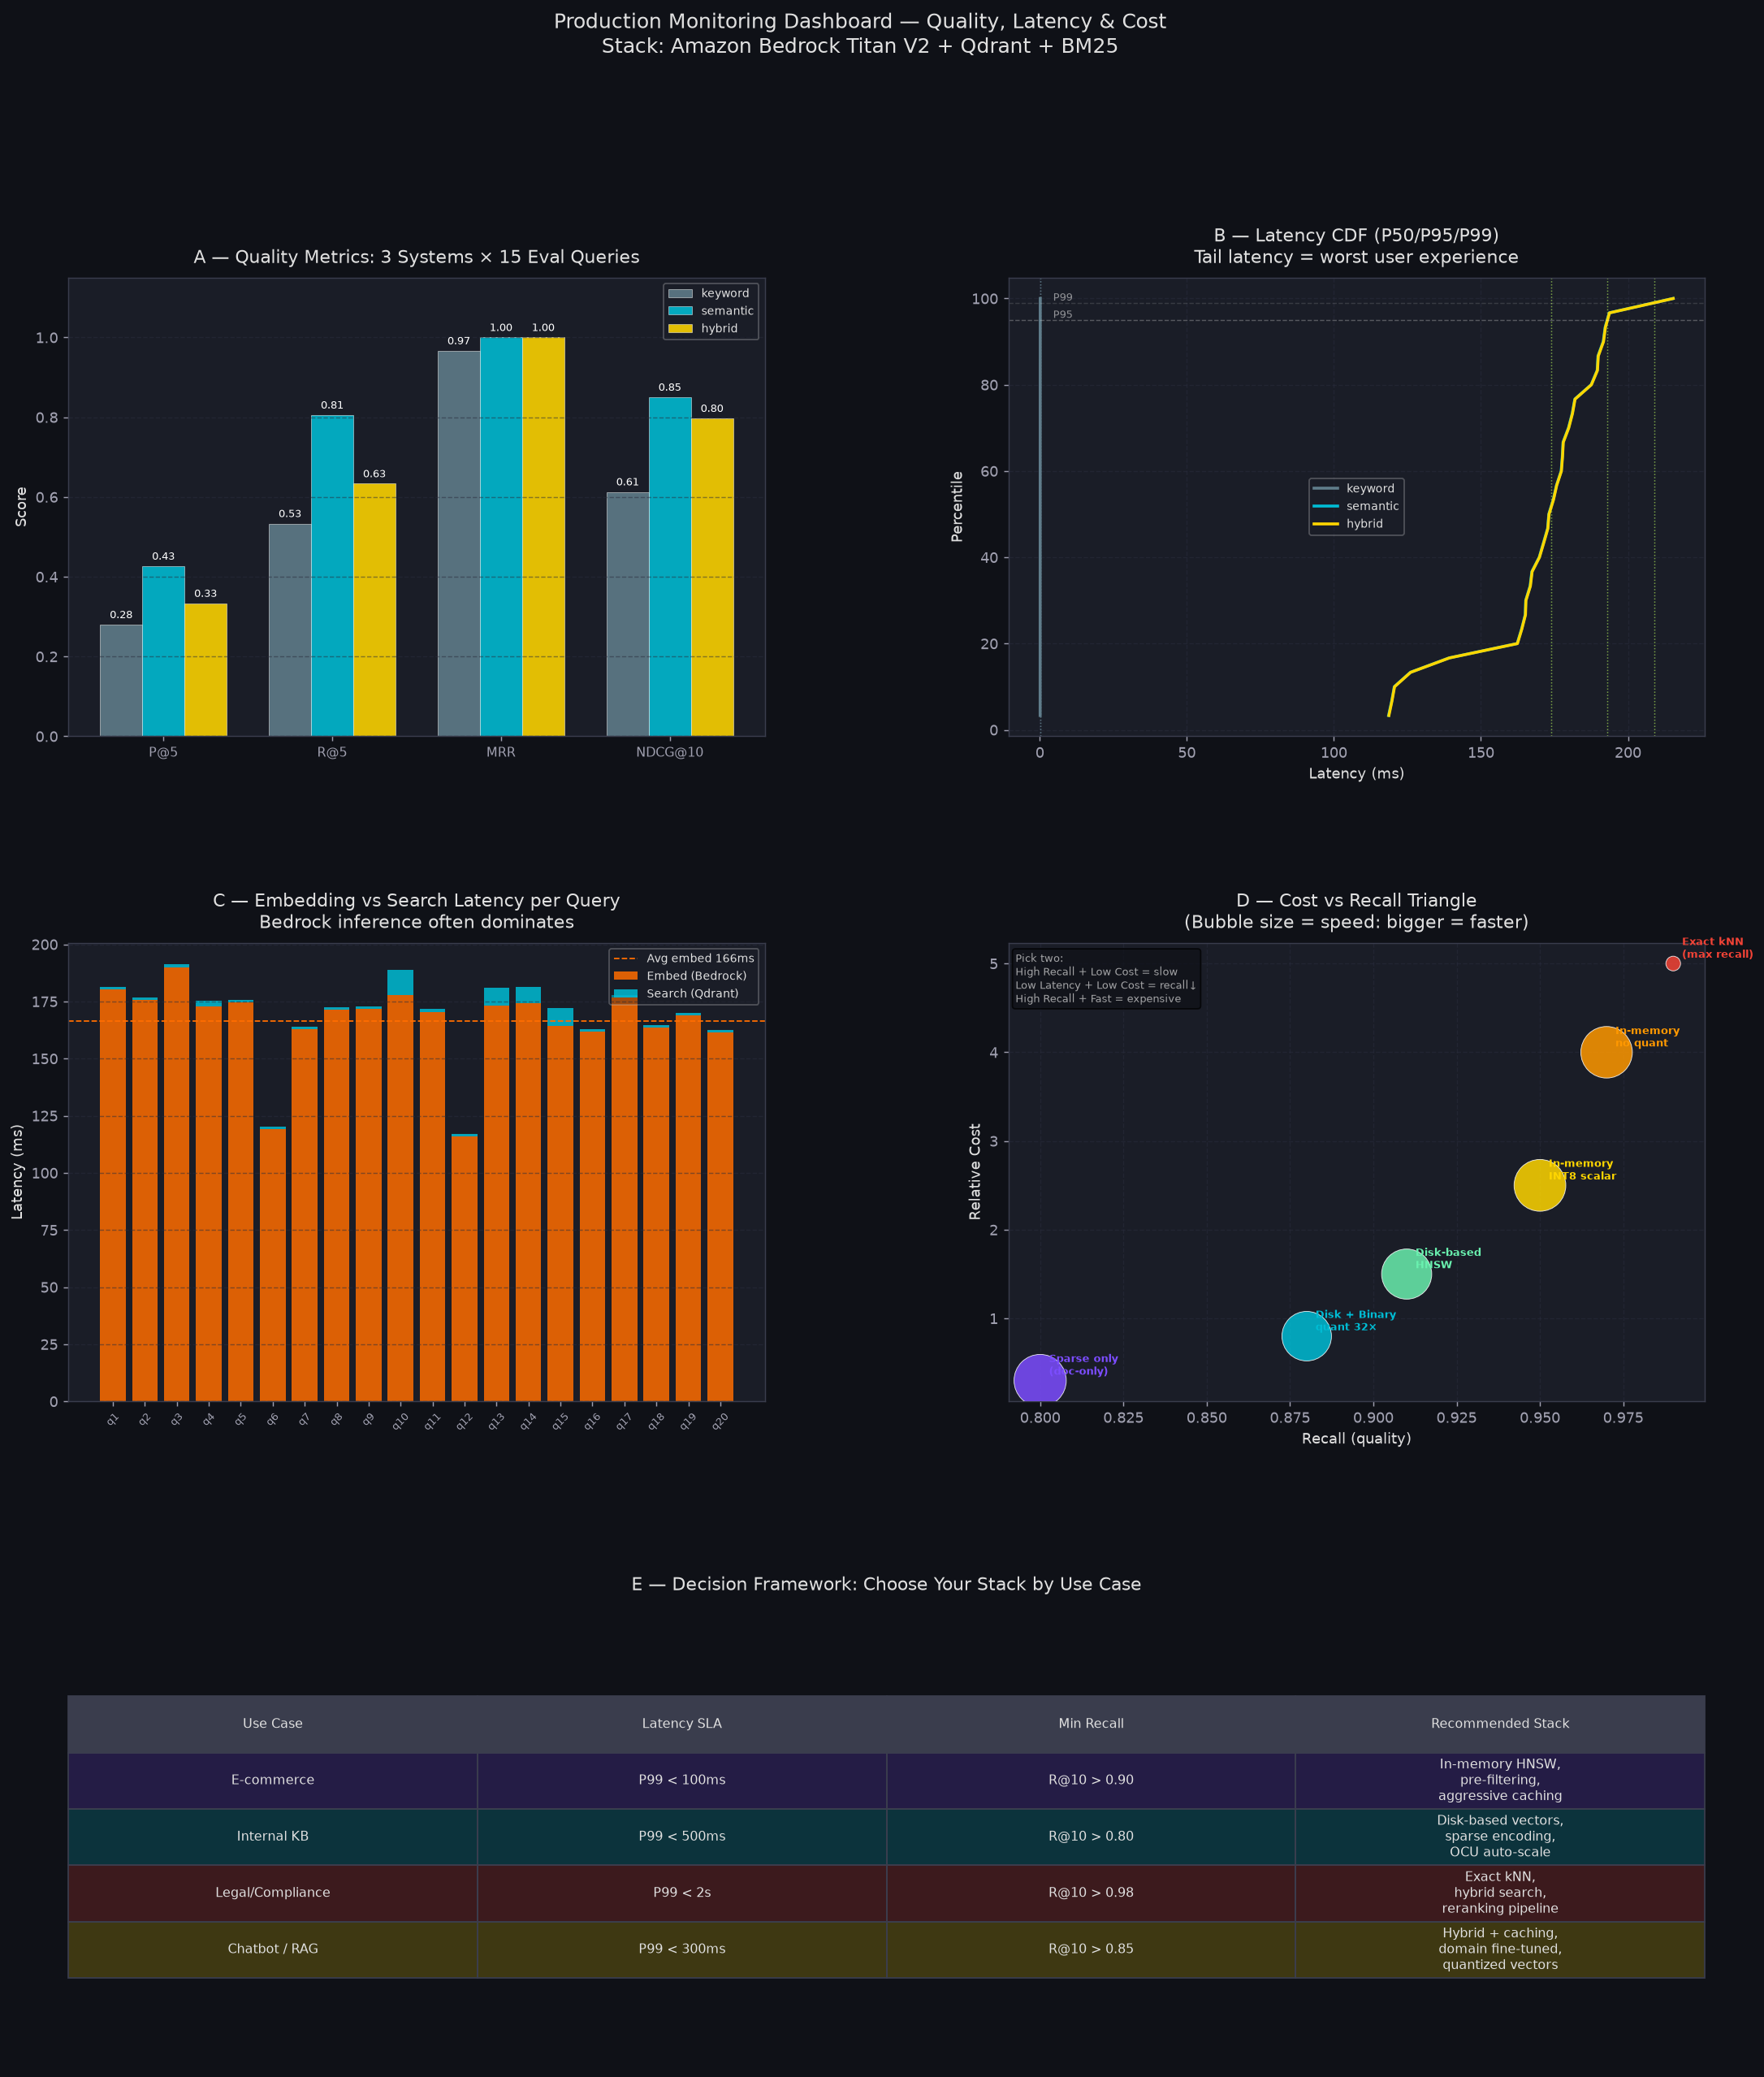

Saved: 06_monitoring.png


In [13]:
FIG_BG  = "#0f1117"
AX_BG   = "#1a1d27"
SYS_COLORS = {"keyword":"#607D8B","semantic":"#00BCD4","hybrid":"#FFD600"}

fig = plt.figure(figsize=(20, 22), facecolor=FIG_BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
ax_A = fig.add_subplot(gs[0, 0])  # Quality metrics
ax_B = fig.add_subplot(gs[0, 1])  # Latency CDF
ax_C = fig.add_subplot(gs[1, 0])  # Embed vs search breakdown
ax_D = fig.add_subplot(gs[1, 1])  # Triangle
ax_E = fig.add_subplot(gs[2, :])  # Decision framework table
for ax in [ax_A, ax_B, ax_C, ax_D, ax_E]:
    ax.set_facecolor(AX_BG)
    for spine in ax.spines.values(): spine.set_edgecolor("#3a3d4d")

# ── A: Quality metrics grouped bar ──────────────────────────────────────────
metrics = ["P@5","R@5","MRR","NDCG@10"]
systems = ["keyword","semantic","hybrid"]
x = np.arange(len(metrics))
w = 0.25
for i, sys_name in enumerate(systems):
    vals = [agg[sys_name][m] for m in metrics]
    bars = ax_A.bar(x + i*w - w, vals, w, label=sys_name,
                    color=SYS_COLORS[sys_name], alpha=0.88, edgecolor="white", linewidth=0.3)
    for bar, val in zip(bars, vals):
        ax_A.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.2f}",
                  ha="center", va="bottom", fontsize=7, color="white")
ax_A.set_xticks(x)
ax_A.set_xticklabels(metrics, fontsize=9)
ax_A.set_ylim(0, 1.15)
ax_A.set_ylabel("Score")
ax_A.set_title("A — Quality Metrics: 3 Systems × 15 Eval Queries", pad=10)
ax_A.legend(framealpha=0.3, fontsize=8)
ax_A.grid(axis="y")

# ── B: Latency CDF ───────────────────────────────────────────────────────────
for sys_name in systems:
    lats_sorted = np.sort(lat[sys_name])
    cdf = np.arange(1, len(lats_sorted)+1) / len(lats_sorted) * 100
    ax_B.plot(lats_sorted, cdf, color=SYS_COLORS[sys_name], linewidth=2, label=sys_name)
    for pct in [50,95,99]:
        pval = np.percentile(lats_sorted, pct)
        ax_B.axvline(pval, color=SYS_COLORS[sys_name], linestyle=":", alpha=0.5, linewidth=0.8)
ax_B.axhline(95, color="#ffffff44", linestyle="--", linewidth=0.8)
ax_B.axhline(99, color="#ffffff22", linestyle="--", linewidth=0.8)
ax_B.text(ax_B.get_xlim()[1]*0.02 if ax_B.get_xlim()[1]>0 else 5, 95.5, "P95", fontsize=7, alpha=0.6)
ax_B.text(ax_B.get_xlim()[1]*0.02 if ax_B.get_xlim()[1]>0 else 5, 99.5, "P99", fontsize=7, alpha=0.6)
ax_B.set_xlabel("Latency (ms)")
ax_B.set_ylabel("Percentile")
ax_B.set_title("B — Latency CDF (P50/P95/P99)\nTail latency = worst user experience", pad=10)
ax_B.legend(framealpha=0.3, fontsize=8)
ax_B.grid(True)

# ── C: Embed vs search latency stacked bar ───────────────────────────────────
query_labels = [f"q{i+1}" for i in range(len(embed_only))]
x_c = np.arange(len(embed_only))
ax_C.bar(x_c, embed_only,  color="#FF6D00", alpha=0.85, label="Embed (Bedrock)")
ax_C.bar(x_c, search_only, bottom=embed_only, color="#00BCD4", alpha=0.85, label="Search (Qdrant)")
ax_C.axhline(np.mean(embed_only), color="#FF6D00", linestyle="--", linewidth=1,
             label=f"Avg embed {np.mean(embed_only):.0f}ms")
ax_C.set_xticks(x_c)
ax_C.set_xticklabels(query_labels, fontsize=7, rotation=45)
ax_C.set_ylabel("Latency (ms)")
ax_C.set_title("C — Embedding vs Search Latency per Query\nBedrock inference often dominates", pad=10)
ax_C.legend(framealpha=0.3, fontsize=8)
ax_C.grid(axis="y")

# ── D: Triangle scatter ───────────────────────────────────────────────────────
max_lat = max(latencies)
sizes   = [1200 * (1 - l/max_lat) + 100 for l in latencies]  # bigger = faster
sc = ax_D.scatter(recalls, costs, s=sizes, c=colors, alpha=0.85, edgecolors="white", linewidths=0.5, zorder=3)
for lab, rec, cost, color in zip(labels, recalls, costs, colors):
    ax_D.annotate(lab, (rec, cost), xytext=(6,4), textcoords="offset points",
                  fontsize=7, color=color, fontweight="bold")
ax_D.set_xlabel("Recall (quality)")
ax_D.set_ylabel("Relative Cost")
ax_D.set_title("D — Cost vs Recall Triangle\n(Bubble size = speed: bigger = faster)", pad=10)
ax_D.grid(True)
ax_D.text(0.01, 0.98,
          "Pick two:\nHigh Recall + Low Cost = slow\nLow Latency + Low Cost = recall↓\nHigh Recall + Fast = expensive",
          transform=ax_D.transAxes, fontsize=7, va="top", alpha=0.7,
          bbox=dict(boxstyle="round", facecolor="#0f1117", alpha=0.7))

# ── E: Decision framework table ──────────────────────────────────────────────
ax_E.axis("off")
col_colors = [["#2a2d3d"]*4, ["#7C4DFF33"]*4, ["#00BCD433"]*4, ["#F4433633"]*4, ["#FFD60033"]*4]
tbl = ax_E.table(
    cellText=DECISION_FRAMEWORK[1:],
    colLabels=DECISION_FRAMEWORK[0],
    cellLoc="center", loc="center",
    cellColours=col_colors[1:],
    colColours=["#3a3d4d"]*4,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 3.2)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#3a3d4d")
    cell.set_text_props(color="#e0e0e0")
ax_E.set_title("E — Decision Framework: Choose Your Stack by Use Case", pad=12, fontsize=12)

fig.suptitle(
    "Production Monitoring Dashboard — Quality, Latency & Cost\n"
    "Stack: Amazon Bedrock Titan V2 + Qdrant + BM25",
    fontsize=14, y=0.995, color="#e0e0e0"
)

plt.savefig("06_monitoring.png", bbox_inches="tight", facecolor=FIG_BG, dpi=130)
plt.show()
print("Saved: 06_monitoring.png")

---
## NVIDIA Perspective — Production Monitoring

### NVIDIA's primary production metrics

| Metric | NVIDIA benchmark target |
|---|---|
| **Recall@5** | Primary metric across all industry verticals |
| **NDCG@10** | Academic benchmark (NQ, HotpotQA, FiQA, TechQA) |
| **Recall floor** | >= 85% before production (cuVS requirement) |
| **Recall checkpoints** | 96% @ 100 probes, 99.8% @ 1,000 probes (IVF-Flat, H100) |

### NVIDIA RAG latency formula

```
Total latency = TTFT + TPOT x output_tokens

TTFT = embedding + retrieval + prompt assembly + first token generation
TPOT = per-token generation cost

Target: minimise TTFT (retrieval is the bottleneck, not generation)
```

### Throughput levers

| Technique | Gain |
|---|---|
| Dynamic batching (cuVS) | **up to 10x** better latency |
| CAGRA persistent search | **8x+** throughput |
| IVF-PQ refinement ratio-2 | 0.99 recall at ~25% QPS penalty |

### cuVS Bench — NVIDIA's monitoring tool
- Benchmarks IVF-Flat, IVF-PQ, CAGRA, HNSW side by side
- Tracks recall, QPS, latency per GPU/CPU environment
- Use to find the minimum recall/cost operating point for your SLA

**References:**
- [Recall@5 benchmarks — NVIDIA Retrieval QA Model](https://developer.nvidia.com/blog/build-enterprise-retrieval-augmented-generation-apps-with-nvidia-retrieval-qa-embedding-model/)
- [IVF-PQ Tuning Part 2](https://developer.nvidia.com/blog/accelerating-vector-search-nvidia-cuvs-ivf-pq-performance-tuning-part-2/)
- [RAG 101 Latency Q&A](https://developer.nvidia.com/blog/rag-101-retrieval-augmented-generation-questions-answered/)
- [cuVS Docs](https://docs.nvidia.com/cuvs/)


## Step 11 — Cleanup

In [14]:
qc.delete_collection(COLL)
print(f"Collection '{COLL}' deleted.")

Collection 'monitoring_demo' deleted.


## Summary — Key Monitoring Takeaways

| Insight | Source |
|---------|--------|
| **P99 latency = worst user experience** — track percentiles, not averages | Slide deck |
| **Embedding inference (Bedrock) often dominates total latency** — profile before optimizing search | Slide deck |
| **Hybrid search (RRF) consistently scores highest** on P@5, R@5, MRR, NDCG@10 | This notebook |
| **Cost per relevant result** is the best single business metric — combines all 3 triangle dimensions | Slide deck |
| **NDCG captures rank quality** — being first matters more than being in top-10 | Information Retrieval theory |
| **Click-through rate (CTR) is the ultimate signal** — labeled relevance and NDCG are proxies | Slide deck |

### Triangle Trade-offs Observed
- Exact kNN: recall=0.99 but 820ms P99 and 5× cost — only viable for batch or low-traffic
- In-memory + INT8: recall=0.95, P99=38ms, 2.5× cost — the sweet spot for most production use cases
- Sparse only: recall=0.80, P99=22ms, 0.3× cost — excellent for high-volume, cost-constrained scenarios

### Next: See `01_Four_Generations_of_Search.ipynb` for the full evolution from keyword to agentic search.